In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/online_retail_final.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Create Invoice Month 

In [4]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

Find Each Customer's First Purchase Month

In [5]:
cohort = df.groupby("CustomerID")["InvoiceMonth"].min()

cohort.head()

CustomerID
12346    2011-01
12347    2010-12
12348    2010-12
12349    2011-11
12350    2011-02
Name: InvoiceMonth, dtype: period[M]

In [6]:
cohort = cohort.rename("CohortMonth")

Merge Cohort Information

In [7]:
df = df.merge(
    cohort,
    on="CustomerID"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend,TotalPrice,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34,2010-12


Calculate Cohort Index

In [8]:
def get_month_diff(invoice, cohort):
    return (
        (invoice.year - cohort.year) * 12
        + (invoice.month - cohort.month)
        + 1
    )

In [9]:
df["CohortIndex"] = df.apply(
    lambda row: get_month_diff(
        row["InvoiceMonth"],
        row["CohortMonth"]
    ),
    axis=1
)

Create Cohort Table

In [10]:
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["CustomerID"].nunique().reset_index()

Create Pivot Table

In [11]:

cohort_pivot = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Calculate Retention Rate

In [12]:
retention = cohort_pivot.divide(
    cohort_pivot.iloc[:,0],
    axis=0
)

retention = retention.round(3)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plot Cohort Heatmap

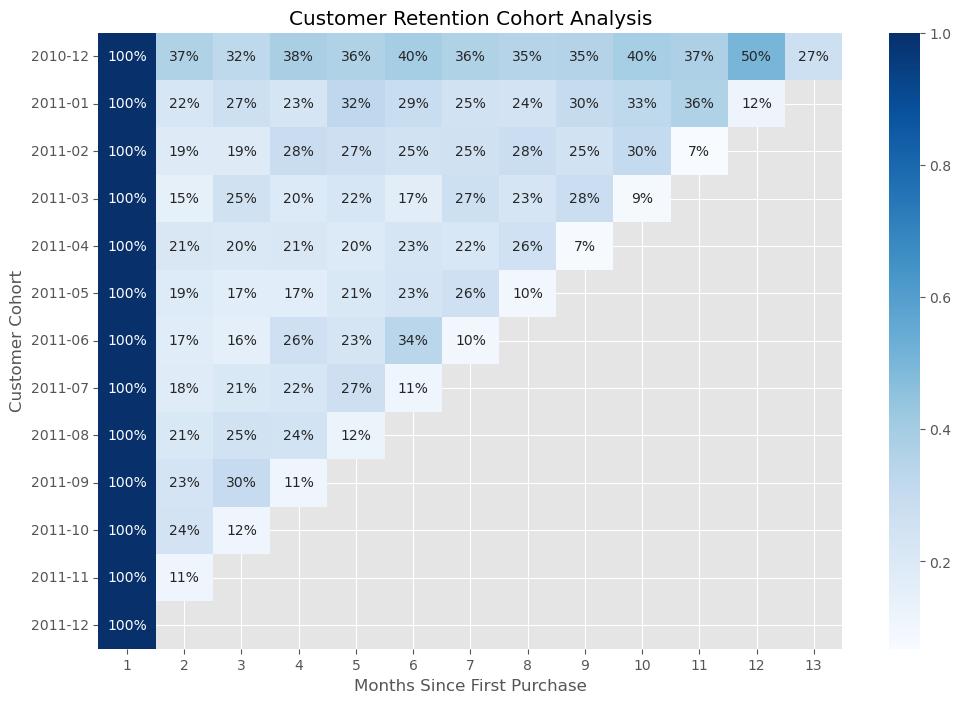

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")

plt.xlabel("Months Since First Purchase")

plt.ylabel("Customer Cohort")

plt.show()

Average Retention

In [14]:
avg_retention = retention.mean()

avg_retention

CohortIndex
1     1.000000
2     0.206167
3     0.221182
4     0.232400
5     0.245444
6     0.250875
7     0.243857
8     0.242500
9     0.250600
10    0.278000
11    0.269000
12    0.310500
13    0.266000
dtype: float64

Plot Average Retention

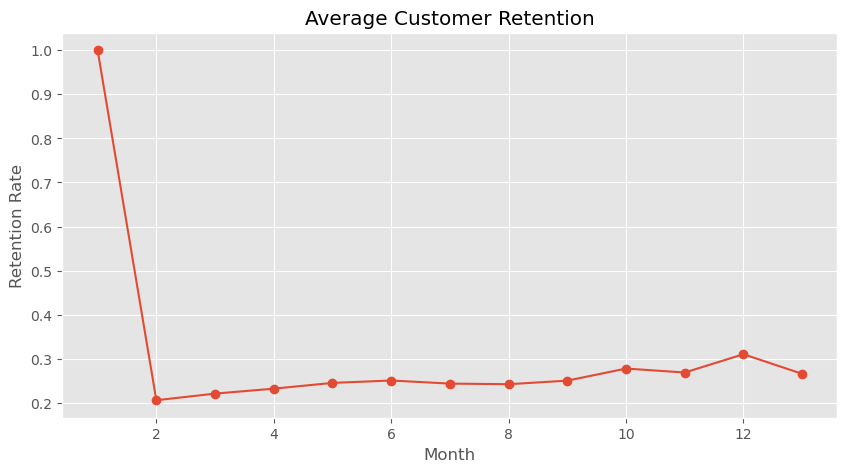

In [15]:
avg_retention.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Average Customer Retention")

plt.xlabel("Month")

plt.ylabel("Retention Rate")

plt.grid(True)

plt.show()

Save Dataset

In [16]:
retention.to_csv(
    "../data/processed/cohort_retention.csv"
)

# Cohort Analysis Insights

## Key Findings

1. Customers are grouped by their first purchase month.
2. The first month always has 100% retention because it is the cohort's starting point.
3. Retention generally decreases over time as some customers stop purchasing.
4. Some cohorts retain customers better than others, indicating stronger engagement.
5. Cohort analysis helps evaluate customer loyalty and the effectiveness of retention strategies.
6. Businesses can use these insights to improve marketing campaigns and customer experience.